In [39]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd 
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default='browser'
import pyarrow.feather as feather
import plotly.express as px
import numpy as np
import yaml


In [40]:
#load model parameters from yaml file
with open('Gonneville_pars.yaml', 'r') as file:
    model_params = yaml.safe_load(file)

#Access parameters


mineral = model_params['response']
covariates = model_params['covariates']


#model_params = model_params['model']

learning_rate = model_params['learning_rate']
batch_size = model_params['batch_size']
epochs = model_params['epochs']
cellsize = model_params['cellsize']
layers = model_params['layers']
dropout = model_params['dropout']
activation = model_params['activation']
loss = model_params['loss']
optimizer = model_params['optimizer']

x = model_params['x']
y = model_params['y']
z = model_params['z']

# plotting parameters
cov_labels = model_params['cov_labels']

# file paths
source_dir = model_params['source_dir']
working_dir = model_params['working_dir']
roi_dir = model_params['roi_dir']

In [41]:
gonneville_data = pd.read_csv(f'{source_dir}/Gonneville_full.csv', low_memory=False)  # Gonneville data
# load ROI coords
ROI = pd.read_csv(f'{roi_dir}/ROI.csv', low_memory=False)

In [42]:
# Assume ROI is a DataFrame with columns: Xmin, Xmax, Ymin, Ymax
# And gonneville_data has columns: mid_x_y, mid_y_y, mid_z_y

#small_ROI = 0
#medium_ROI = 1
#large_ROI = 2

roi_row = 0  # Change this to select the desired ROI row


xmin, xmax = ROI['Xmin'].iloc[roi_row], ROI['Xmax'].iloc[roi_row]
ymin, ymax = ROI['Ymin'].iloc[roi_row], ROI['Ymax'].iloc[roi_row]

filtered_gonneville = gonneville_data[
    (gonneville_data['mid_x_y'] >= xmin) & (gonneville_data['mid_x_y'] <= xmax) &
    (gonneville_data['mid_y_y'] >= ymin) & (gonneville_data['mid_y_y'] <= ymax)
]

In [43]:
#df = density_data.copy()
df = filtered_gonneville.copy()

#filtered_samples = df.dropna(subset=['Alt1_Code', 'Alt2_Code', 'Density_gcm3'])
#sample_list = Gonneville_pars(response+covariates) # TODO fix this with Yaml
filtered_samples = df.dropna(subset=covariates)
cols = [mineral] + covariates 
combined_data = df[cols].dropna()
#deposit_data = deposit_data.dropna

sample_count = len(filtered_samples)
perc = (sample_count/len(df))*100 
#print(f"Number of samples with alteration and Density_gcm3 data: {sample_count}")
#print(f"Number of samples with gold and pathfinder (As, Hg) data: {sample_count}")
print(f"Number of samples with Pd and 'important feature' (Pt_ppm, Ni_ppm, Co_ppm, Cr_ppm, Cu_ppm, Lith1_code) data: {sample_count}")
#print(f"This is " {perc} " percent of the dataset") 
print(perc)

Number of samples with Pd and 'important feature' (Pt_ppm, Ni_ppm, Co_ppm, Cr_ppm, Cu_ppm, Lith1_code) data: 20665
99.6768280918387


In [44]:
# Calculate the percentage of the volume that has been sampled by drilling

# Volume of a cylinder = π * r^2 * h
# Assuming a drill core diameter of 10 cm and an interval length of 1 m

# core diameters: AQ: 0.027 m; BQ: 0.0365 m; NQ: 0.0476 m; HQ: 0.0635 m; PQ: 0.085 m 

drill_core_diameter = 0.0635  # in meters
drill_core_radius = drill_core_diameter / 2
drill_core_interval_length = 1 # in meters
# multiply by the number of samples to get the total volume sampled
drill_core_volume = np.pi * (drill_core_radius ** 2) * drill_core_interval_length * len(combined_data) # in cubic meters

# Volume of the domain

domain_volume = (xmax - xmin) * (ymax - ymin) * (df['mid_z_y'].max() - df['mid_z_y'].min())  # in cubic meters
sampled_volume = sample_count * drill_core_volume  # in cubic meters
sampled_volume_percentage = (sampled_volume / domain_volume) * 100
print(f"Sampled volume percentage: {sampled_volume_percentage:.2f}%")



Sampled volume percentage: 5.09%


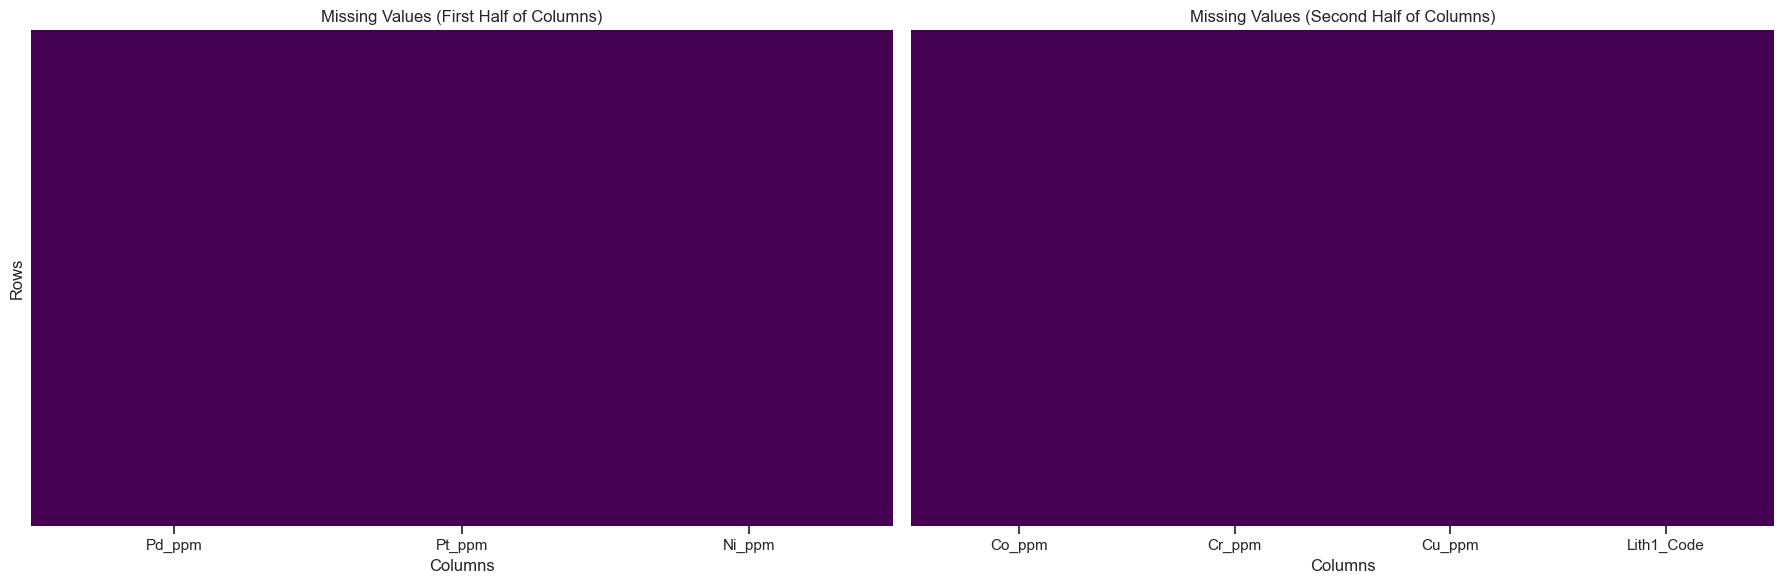

In [45]:
# Plot missing values in merged_df as two separate heatmaps: 
# 1. For the first half of columns, 2. For the second half

import matplotlib.pyplot as plt
import seaborn as sns

n_cols = combined_data.shape[1]
mid = n_cols // 2

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

# First half of columns
sns.heatmap(
    combined_data.iloc[:, :mid].isnull(),
    cbar=False, yticklabels=False, cmap='viridis', ax=axes[0]
)
axes[0].set_title('Missing Values (First Half of Columns)')
axes[0].set_xlabel('Columns')
axes[0].set_ylabel('Rows')

# Second half of columns
sns.heatmap(
    combined_data.iloc[:, mid:].isnull(),
    cbar=False, yticklabels=False, cmap='viridis', ax=axes[1]
)
axes[1].set_title('Missing Values (Second Half of Columns)')
axes[1].set_xlabel('Columns')

plt.tight_layout()
plt.show()

In [46]:
# log transform the data
# TODO yaml
#deposit_data['Log_Pd_ppm'reponses] = np.log(deposit_data[Pd_ppm])

plot_data = combined_data.copy()
plot_data[f'Log_{mineral}'] = np.log(combined_data[mineral]+0.00001)
cols_to_add = [x, y, z]
plot_data = pd.concat([plot_data, filtered_gonneville[cols_to_add]], axis=1)

#TODO get all this from Yaml
# Create 3D scatter plot
fig = px.scatter_3d(plot_data, \
                    x=x, y=y, z=z, \
                    #x='x', y='y', z='z', \ #YAML
                        color=f'Log_{mineral}', \
                        opacity=0.7, labels={f'Log_{mineral}': f'{mineral}'})

fig.update_traces(marker=dict(line=dict(width=0)))
# Show plot
fig.show()

In [47]:
# Find columns with object or category dtype
categorical_cols = combined_data.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_data = combined_data[categorical_cols]

encoded_data = categorical_data.copy()

threshold = 1 # minimum unique values for one-hot encoding

for column in categorical_data.columns:
    if categorical_data[column].dtype == 'object':
        unique_values = categorical_data[column].nunique()
        
        if unique_values > threshold:
            encoded_columns = pd.get_dummies(encoded_data[column], prefix=column)
            encoded_columns = encoded_columns.astype(int)  
            encoded_data = pd.concat([encoded_data, encoded_columns], axis=1)
            encoded_data = encoded_data.drop(columns=[column])




encoded_columns = [col for col in encoded_data.columns if '_Code_' in col]

total_columns = []
'''
for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    total_columns.append(total_column)
    
    encoded_data[total_column] = (
        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    )

total_columns = []

category_totals = {}

for col in encoded_columns:
    prefix, original_column = col.split('_Code_')
    
    total_column = f"{original_column}_Total"
    if total_column not in total_columns:
        total_columns.append(total_column)
    
    total_values = encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]
    
    if total_column in category_totals:
        category_totals[total_column] += total_values
    else:
        category_totals[total_column] = total_values

for total_column, total_values in category_totals.items():
    encoded_data[total_column] = total_values
'''

'\nfor col in encoded_columns:\n    prefix, original_column = col.split(\'_Code_\')\n    \n    total_column = f"{original_column}_Total"\n    total_columns.append(total_column)\n    \n    encoded_data[total_column] = (\n        encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]\n    )\n\ntotal_columns = []\n\ncategory_totals = {}\n\nfor col in encoded_columns:\n    prefix, original_column = col.split(\'_Code_\')\n    \n    total_column = f"{original_column}_Total"\n    if total_column not in total_columns:\n        total_columns.append(total_column)\n    \n    total_values = encoded_data[f"{prefix}_Code_{original_column}"] * encoded_data[f"{prefix}_Pct"]\n    \n    if total_column in category_totals:\n        category_totals[total_column] += total_values\n    else:\n        category_totals[total_column] = total_values\n\nfor total_column, total_values in category_totals.items():\n    encoded_data[total_column] = total_values\n'

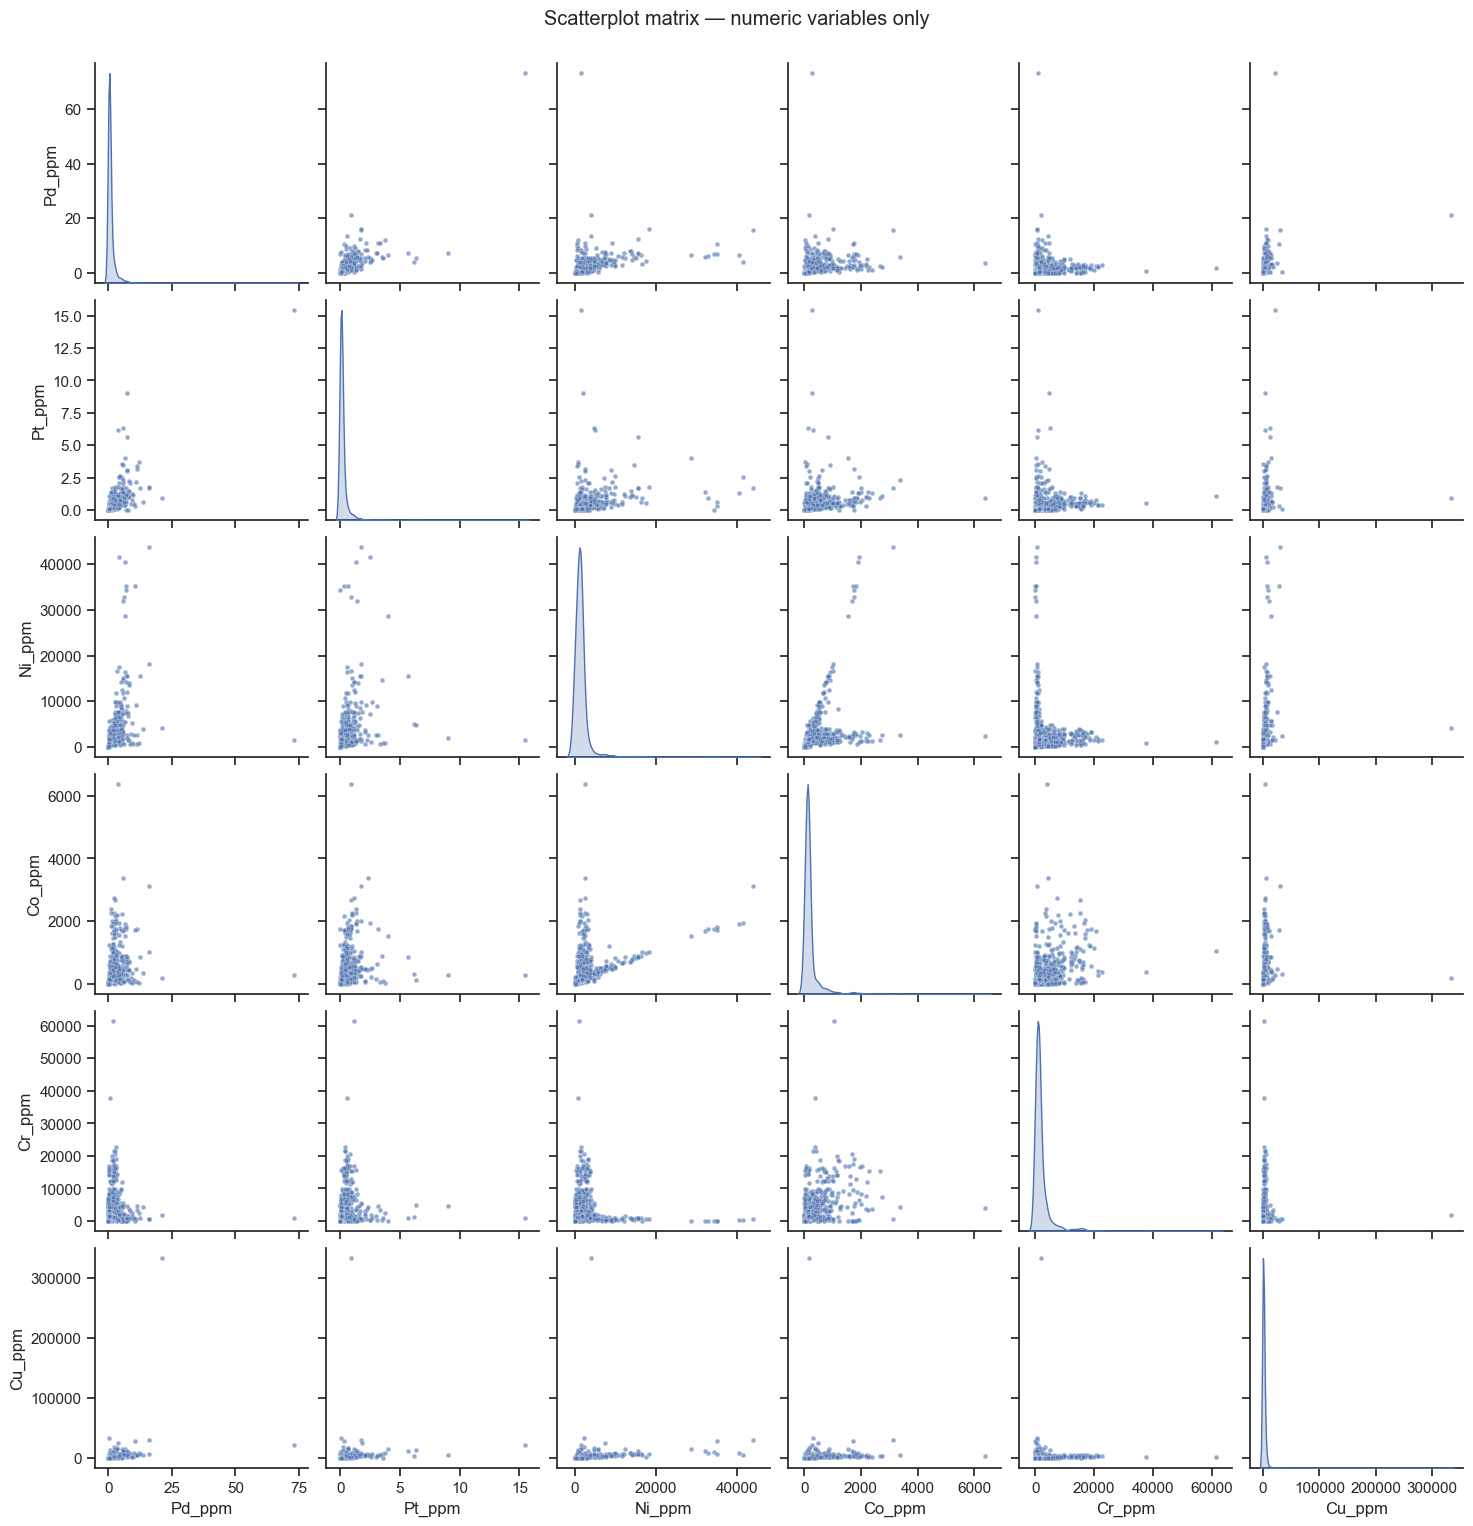

In [50]:

import seaborn as sns

# candidate variables (response + covariates)
candidate_vars = [mineral] + covariates

# keep only variables that exist in the DataFrame and are numeric
vars_to_plot = [
    v for v in candidate_vars
    if v in combined_data.columns and pd.api.types.is_numeric_dtype(combined_data[v])
]

if not vars_to_plot:
    print("No numeric variables to plot. Candidates:", candidate_vars)
else:
    # drop rows with NA in the selected vars and optionally subsample for speed
    df_plot = combined_data[vars_to_plot].dropna()
    if len(df_plot) > 2000:
        df_plot = df_plot.sample(2000, random_state=42)

    sns.set_theme(style="ticks")
    pair = sns.pairplot(df_plot, diag_kind="kde", plot_kws={"s": 12, "alpha": 0.6})
    pair.figure.suptitle("Scatterplot matrix — numeric variables only", y=1.02)
    plt.show()


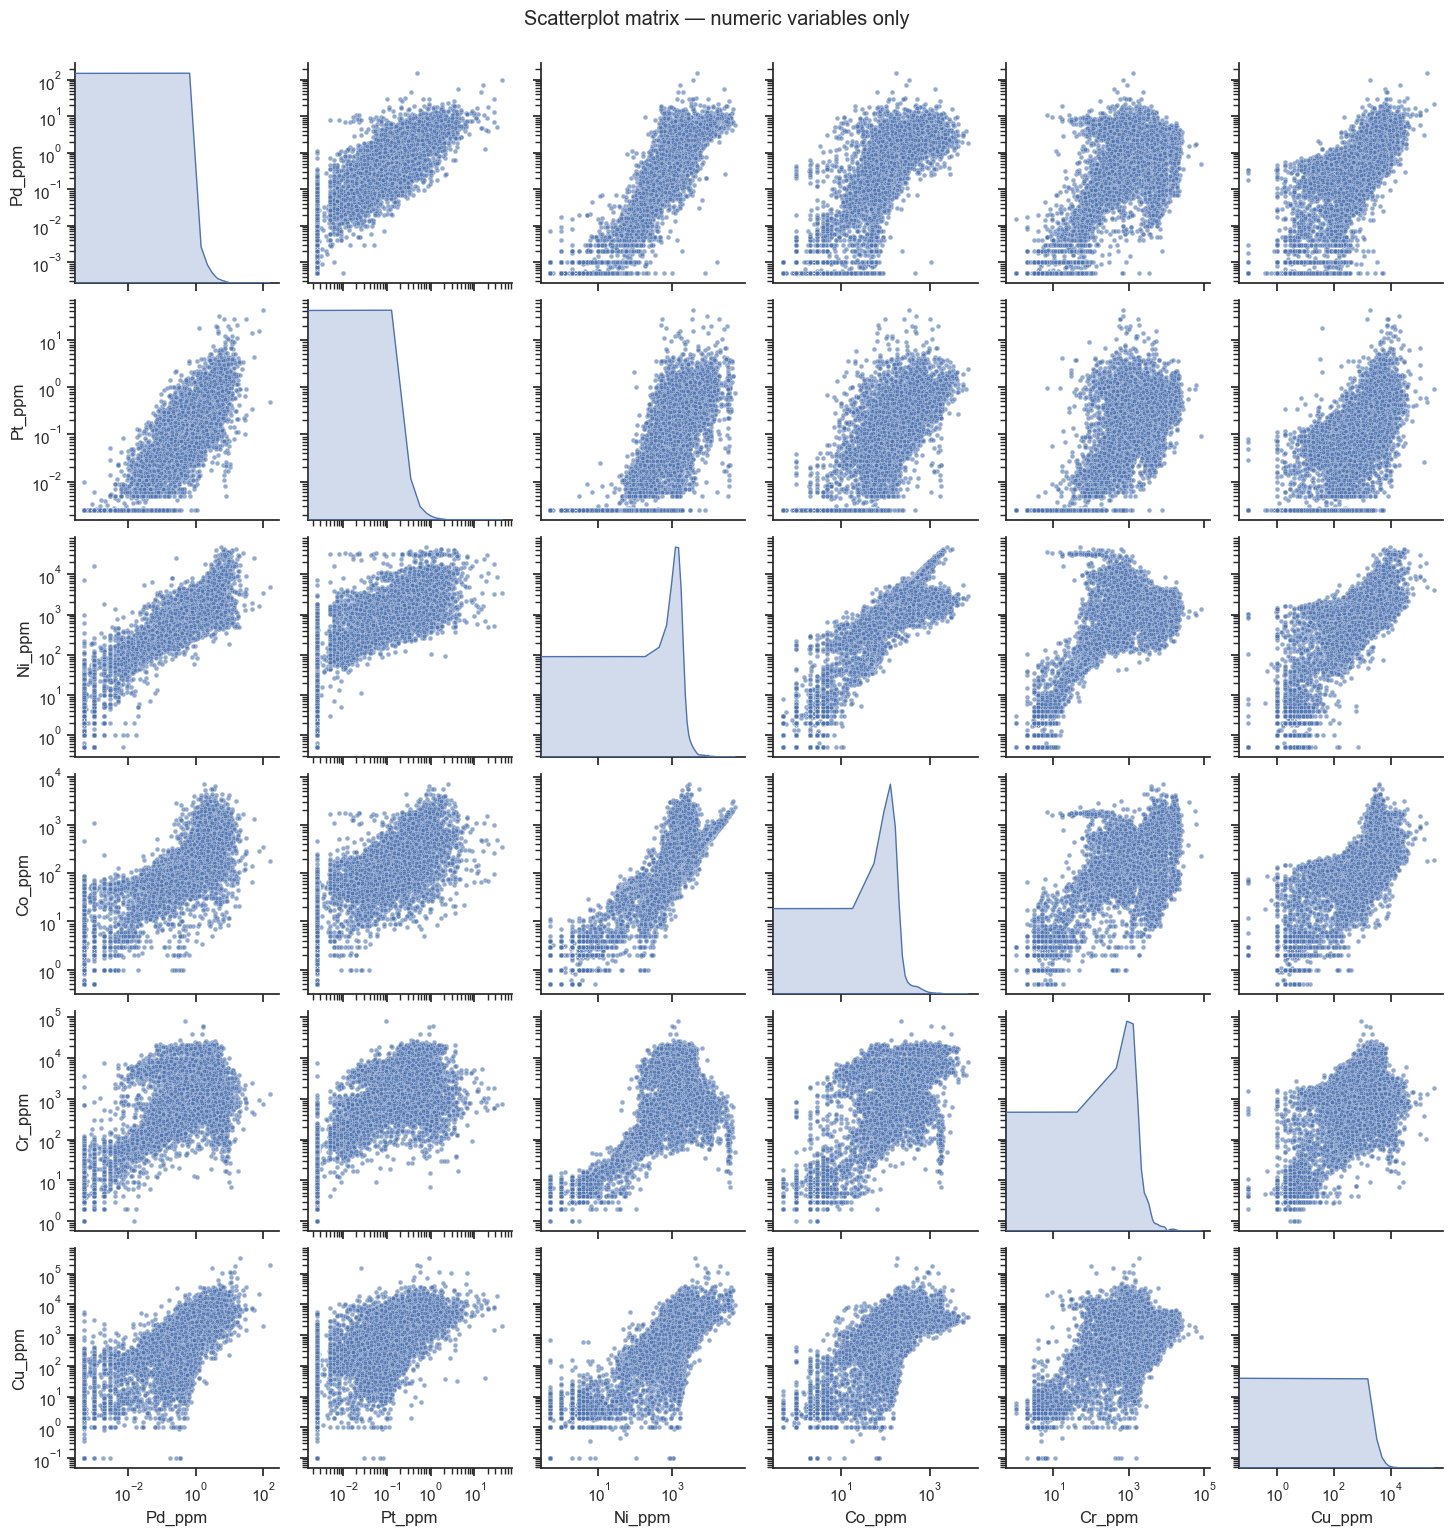

In [51]:
# ...existing code...
# candidate variables (response + covariates)
candidate_vars = [mineral] + covariates
vars_to_plot = [v for v in candidate_vars if v in combined_data.columns and pd.api.types.is_numeric_dtype(combined_data[v])]

# choose which variables to display on a log axis (example)
#log_vars = ['Pd_ppm', 'Au_ppm']  # replace with your variable names
log_vars = [mineral] + covariates  # replace with your variable names

# drop rows with NA for selected plotting vars
df_plot = combined_data[vars_to_plot].dropna()

# remove non-positive values for log_vars
for lv in log_vars:
    if lv in df_plot.columns:
        df_plot = df_plot[df_plot[lv] > 0]

# optional subsample
#if len(df_plot) > 2000:
#    df_plot = df_plot.sample(2000, random_state=42)

g = sns.pairplot(df_plot, diag_kind="kde", plot_kws={"s": 12, "alpha": 0.6})
#g = sns.PairGrid(df_plot)
#g.map_upper(sns.scatterplot)
#g.map_lower(sns.kdeplot)
#g.map_diag(sns.kdeplot, lw=3, legend=False)

vars_list = df_plot.columns.tolist()
for i, yvar in enumerate(vars_list):
    for j, xvar in enumerate(vars_list):
        ax = g.axes[i, j]
        if xvar in log_vars:
            ax.set_xscale('log')
        if yvar in log_vars:
            ax.set_yscale('log')

g.fig.suptitle("Scatterplot matrix — numeric variables only", y=1.02)
plt.show()
# ...existing code...


Column: Lith1_Code
 Lith1_Code
UOMS     11104
MD        1703
GA        1316
XCY       1222
MGB       1203
UPX       1068
XLP        732
XCYM       394
$MS        306
XCYU       287
UOMC       227
$SD        223
$MX        148
LGB        116
TLAT        99
GQ          98
TGRV        71
SHP         68
CY          50
XCYF        35
GP          24
FLT         22
TCY         19
$SS         19
XUSU        17
CLOSS       13
DLAT        12
DHPN        11
DFER         9
TSND         8
XLM          8
XCYu         7
MA           6
TMOT         5
XLN          4
TSL          3
TELV         2
SIF          2
MGBTi        2
DSIL         1
TCYP         1
Name: count, dtype: int64


/var/folders/w4/w0jphlm16_q_7_x766w1p5rm0000gp/T/ipykernel_97140/970908512.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




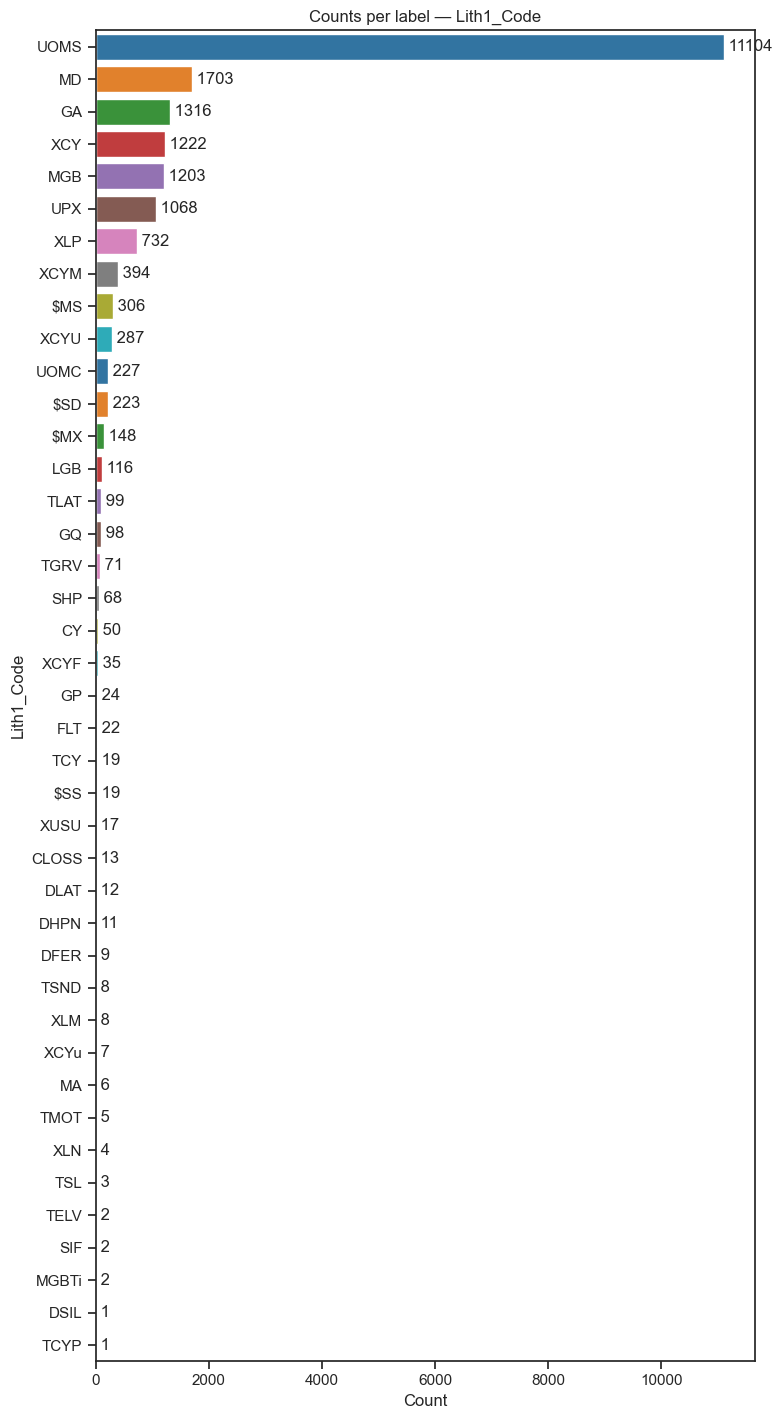

In [52]:
# ...existing code...
import seaborn as sns

# get categorical columns
categorical_cols = combined_data.select_dtypes(include=['object','category']).columns.tolist()

for col in categorical_cols:
    counts = combined_data[col].fillna('NaN').value_counts()
    print(f"\nColumn: {col}\n", counts)

    plt.figure(figsize=(8, max(3, len(counts) * 0.35)))
    sns.barplot(x=counts.values, y=counts.index, palette='tab10')
    plt.xlabel('Count')
    plt.ylabel(col)
    plt.title(f'Counts per label — {col}')

    # add count labels on bars
    for i, v in enumerate(counts.values):
        plt.text(v, i, f' {v}', va='center')

    plt.tight_layout()
    plt.show()
# ...existing code...

## Export un-normalised data

In [ ]:
# export unnormalised deposit data
combined_data = pd.concat([combined_data, filtered_gonneville[cols_to_add]], axis=1)


combined_data.to_csv(f'{working_dir}/filtered_unnormalised_deposit_data.csv', index=False)




In [ ]:
columns_to_normalize = [x] + [y] + [z]

min_values = combined_data[columns_to_normalize].min()

for column in columns_to_normalize:
    combined_data[column] = combined_data[column] - min_values[column]

# Calculate the minimum and maximum values from all three variables
min_values = combined_data[columns_to_normalize].min().min()
max_values = combined_data[columns_to_normalize].max().max()

for column in columns_to_normalize:
    combined_data[column] = (combined_data[column] - min_values) / (max_values - min_values)


In [ ]:

#Scale the rest of the covariates in their own scale
#covariates = ['As_ppm_BESTEL', 'Hg_ppm_BESTEL']
# delete 'log' columns that were used for visualisation
delete_cols = ['Log_Pd_ppm']

try:
    combined_data = combined_data.drop(columns=delete_cols, axis=1)
except Exception:
    pass


exclude_cols = [[x] + [y] + [z]] # exclude x, y, z from scaling as they are coordinates and have been normalized
numeric_cols = combined_data.select_dtypes(include='number').columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

print(numeric_cols)

scaler = MinMaxScaler()
combined_data.loc[:, numeric_cols] = scaler.fit_transform(combined_data.loc[:,numeric_cols])


In [ ]:
all_indexes = combined_data.index
all_indexes.to_series().to_csv('C:/Users/lin236/Documents/DK_Data_PC/indexes.csv', index=False)


In [ ]:
#deposit_data.to_csv('C:/Users/lin236/Documents/DK_Data_PC/filtered_deposit_data.csv', index=False)
path = f"{working_dir}/combined_data.csv"
combined_data.to_csv(path, index=False)

In [ ]:
combined_data.values[:, 8]